# TUS simulation safety parameter plots

In [1]:
import utils
import os
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

pd.set_option('display.max_rows', None)

In [2]:
planning_simulations = False

# Determine simulation location
if planning_simulations:
    simulations_location = 'planning'
else:
    simulations_location = 'post-hoc'

# Make output folder
plot_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/acoustic_simulations/{simulations_location}'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [3]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/{simulations_location}/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-048/sub-048_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-049/sub-049_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-052/sub-052_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-053/sub-053_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-054/sub-054_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-055/sub-055_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-057/sub-057_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [4]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0            48  34.487590                   14.242740             0.000000   
1            49  30.796370                   16.618180             0.500000   
2            52  33.875290                   12.712930             0.000000   
3            53  30.928600                   16.466550             3.000000   
4            54  32.823130                   15.626890             0.500000   
5            55  28.507680                    8.059263             0.000000   
6            57  31.610670                   15.551250             0.500000   
7            58  38.138940                   16.075150             0.000000   
8            59  29.542250                   12.981940             1.000000   
9            60  38.756810                   20.350730             0.000000   
10           61  38.489510                   15.437810             1.500000   
11           63  28.306850                   16.3844

### Reorder the dataframe and replace strings

In [5]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)

# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

# Split target up into two
stimulation_output[['main_target', 'sub_target']] = stimulation_output['target'].str.extract(r'(target_\d+)_(\d+)')

print(stimulation_output)

     subject_id  CEM43_end_skull  CEM43_end_skin      target  max_Isppa  \
0            39         0.001855        0.000587  target_1_1  44.697450   
1            39         0.002409        0.001145  target_1_2  31.553530   
2            39         0.004860        0.001888  target_1_3  41.822680   
3            39         0.005499        0.002588  target_1_4  28.971100   
4            39         0.008341        0.003502  target_1_5  42.281800   
5            39         0.008977        0.004009  target_1_6  31.224480   
6            39         0.000874        0.000476  target_2_1  16.816050   
7            39         0.001527        0.000965  target_2_2  11.571810   
8            39         0.002707        0.001728  target_2_3  15.745000   
9            39         0.003410        0.002194  target_2_4  19.712880   
10           39         0.005225        0.003162  target_2_5  18.443510   
11           39         0.006031        0.003545  target_2_6  24.217980   
12           39         0

# Mechanical index
1.9 is the safety limit
Group by target and intensity

In [6]:
safety_limit = 1.9

## Skin

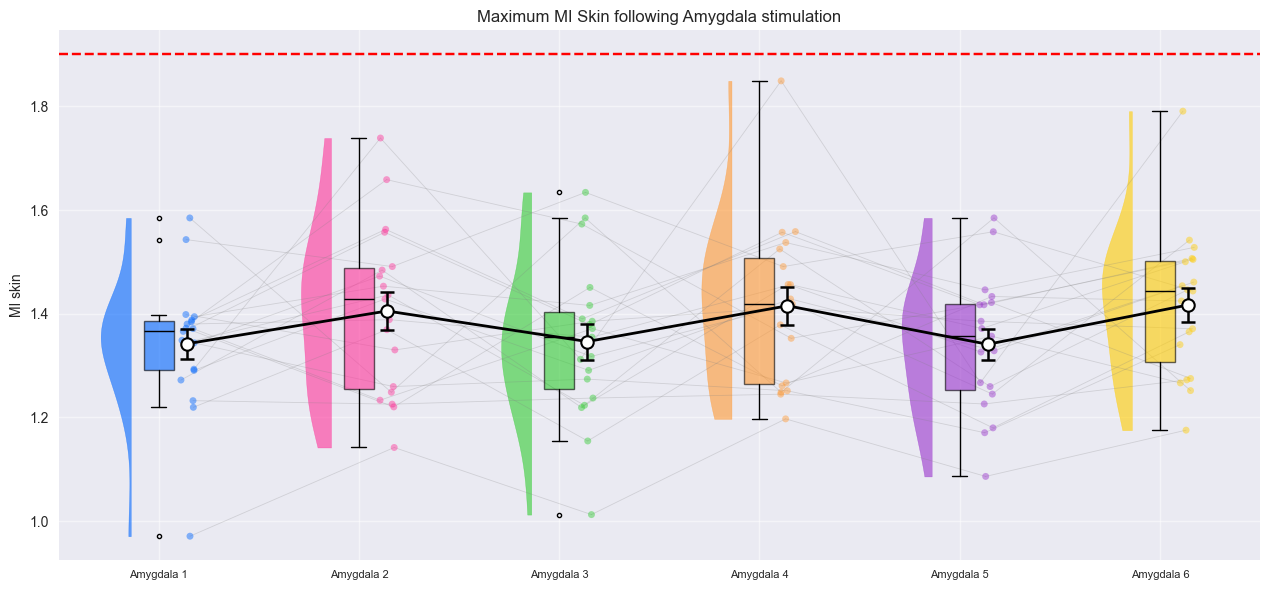

In [7]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following Amygdala stimulation'
);

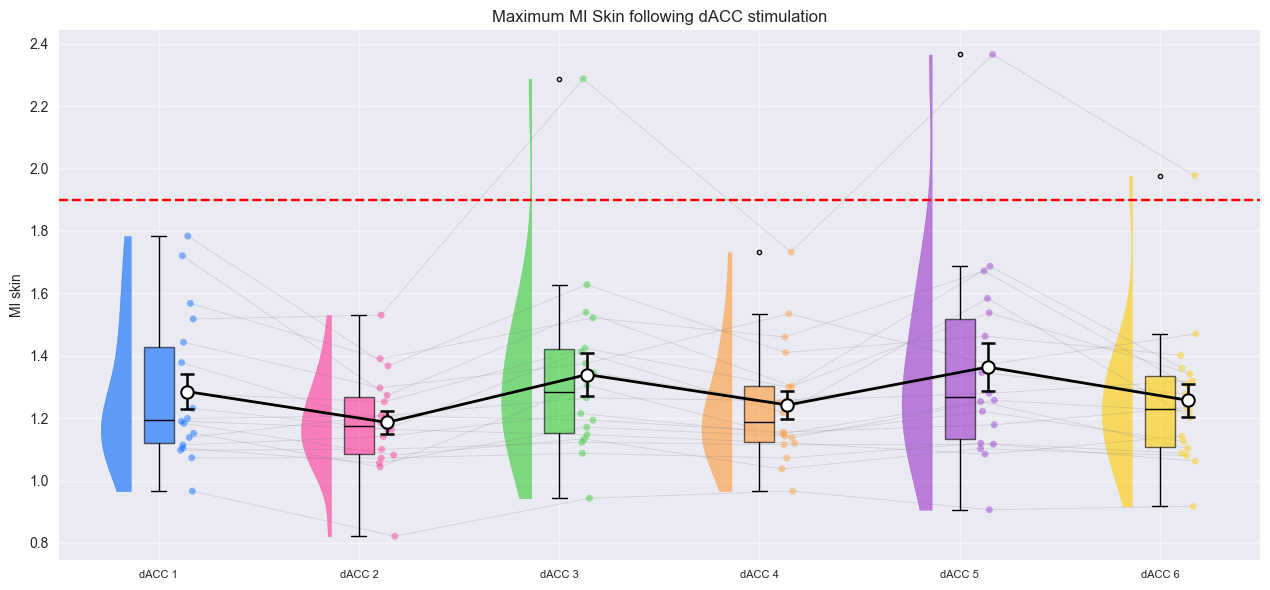

In [8]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following dACC stimulation'
);

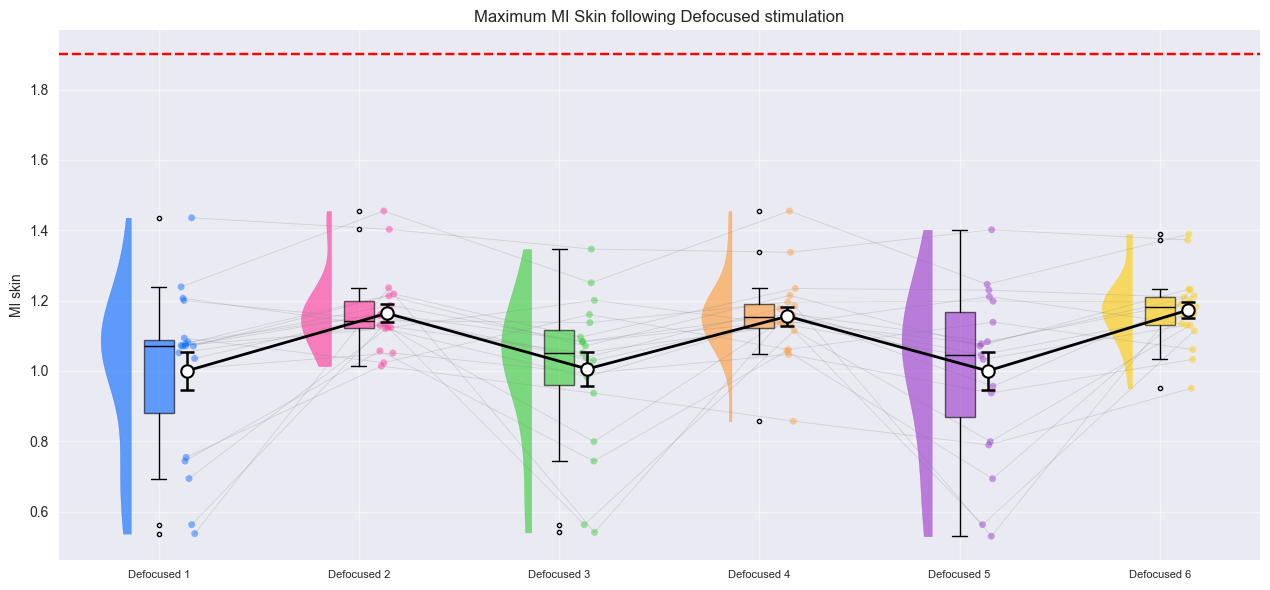

In [9]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin following Defocused stimulation'
);

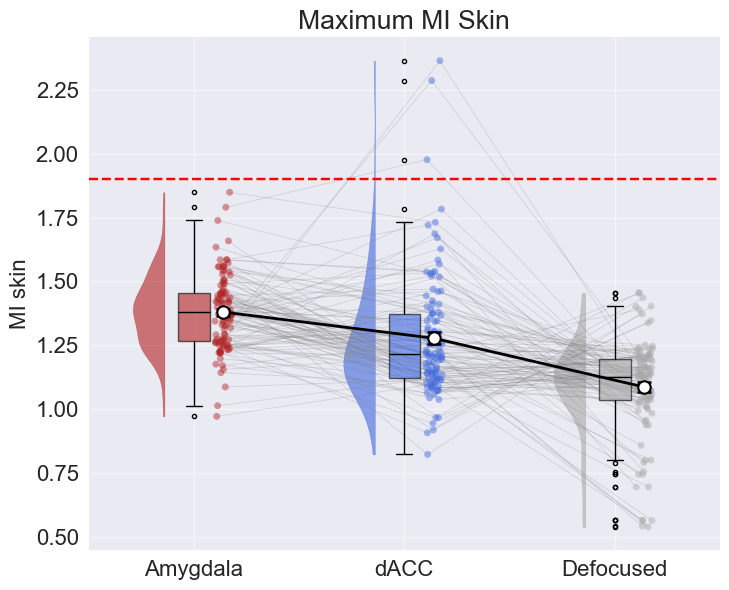

In [10]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='MI skin',
    hline=safety_limit,
    plot_name='Maximum MI Skin',
    font_scale=1.6
);

In [11]:
stimulation_output_exceeded = stimulation_output[stimulation_output['max_MI_skin'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','max_MI_skin']])

     subject_id      target  max_MI_skin
239          64  target_2_3     2.287431
241          64  target_2_5     2.365289
242          64  target_2_6     1.977268


## Brain

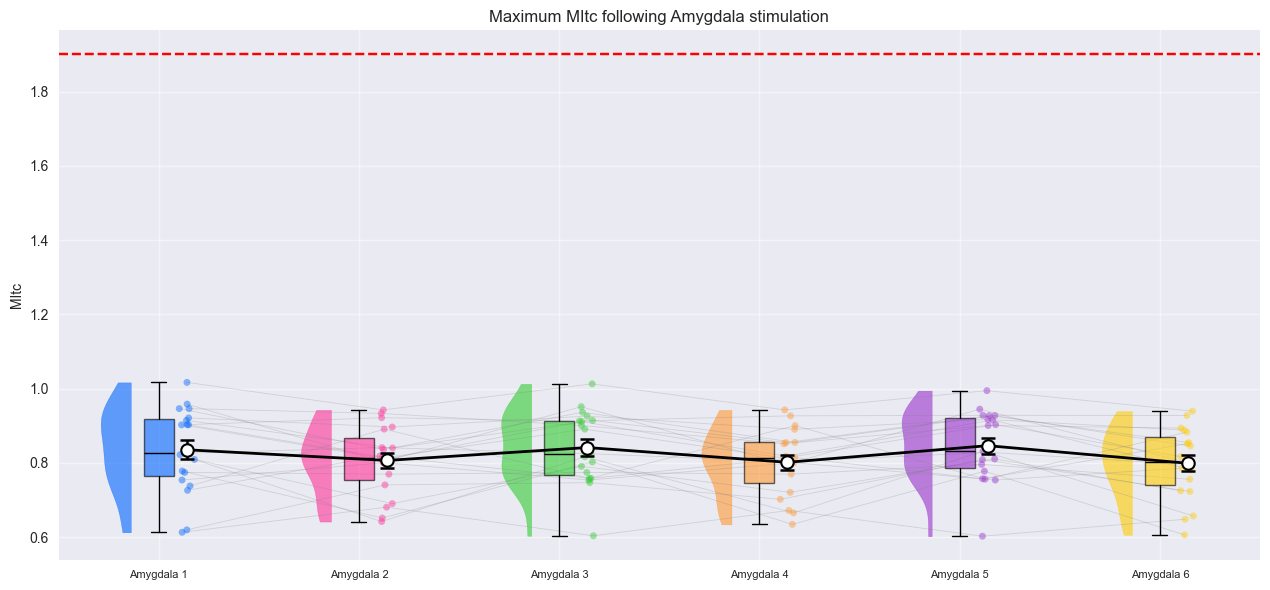

In [12]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following Amygdala stimulation'
);

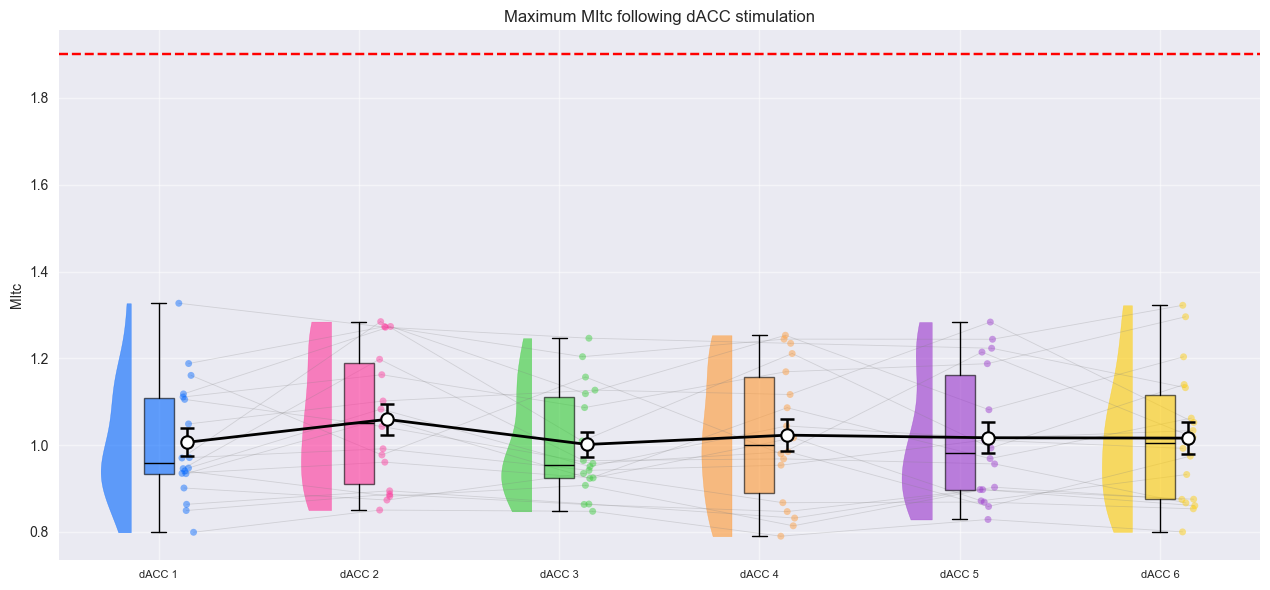

In [13]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following dACC stimulation'
);

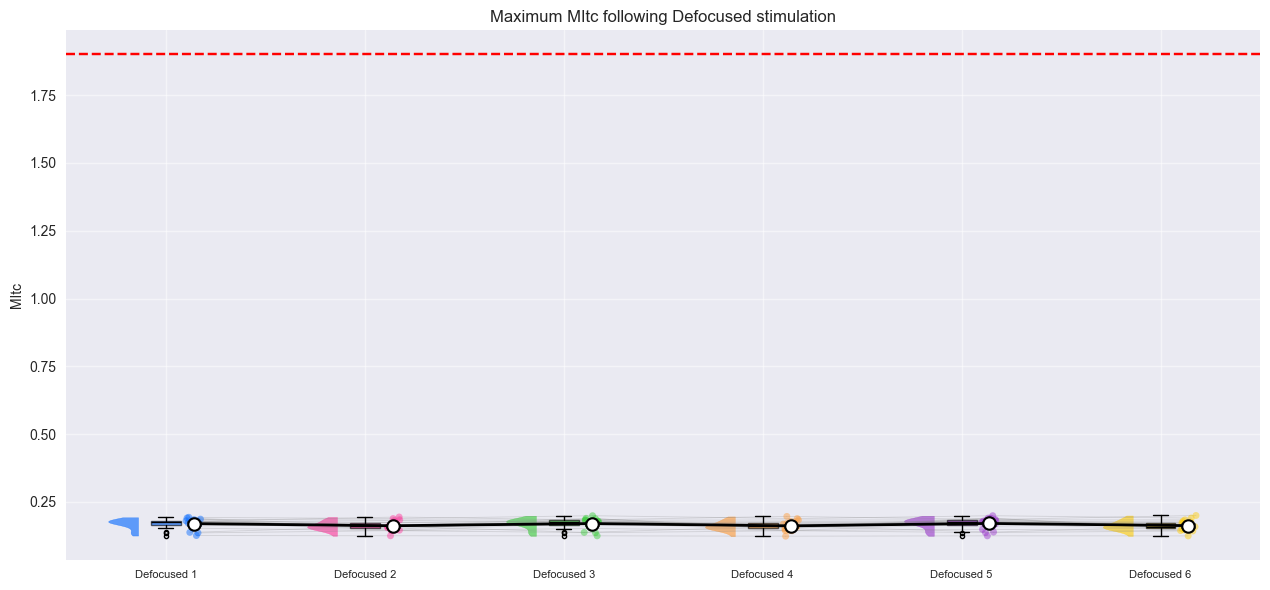

In [14]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc following Defocused stimulation'
);

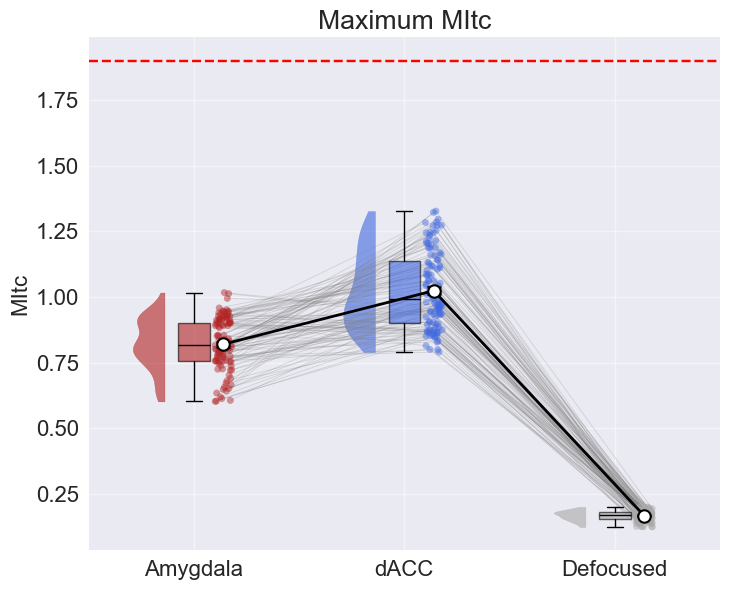

In [15]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='MItc',
    hline=safety_limit,
    plot_name='Maximum MItc',
    font_scale=1.6
);

In [16]:
stimulation_output_exceeded = stimulation_output[stimulation_output['max_MI_brain'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','max_MI_brain']])

Empty DataFrame
Columns: [subject_id, target, max_MI_brain]
Index: []


# CEM43
0.25 is the safety limit
Group by target and intensity

## Skin

In [17]:
safety_limit = 21

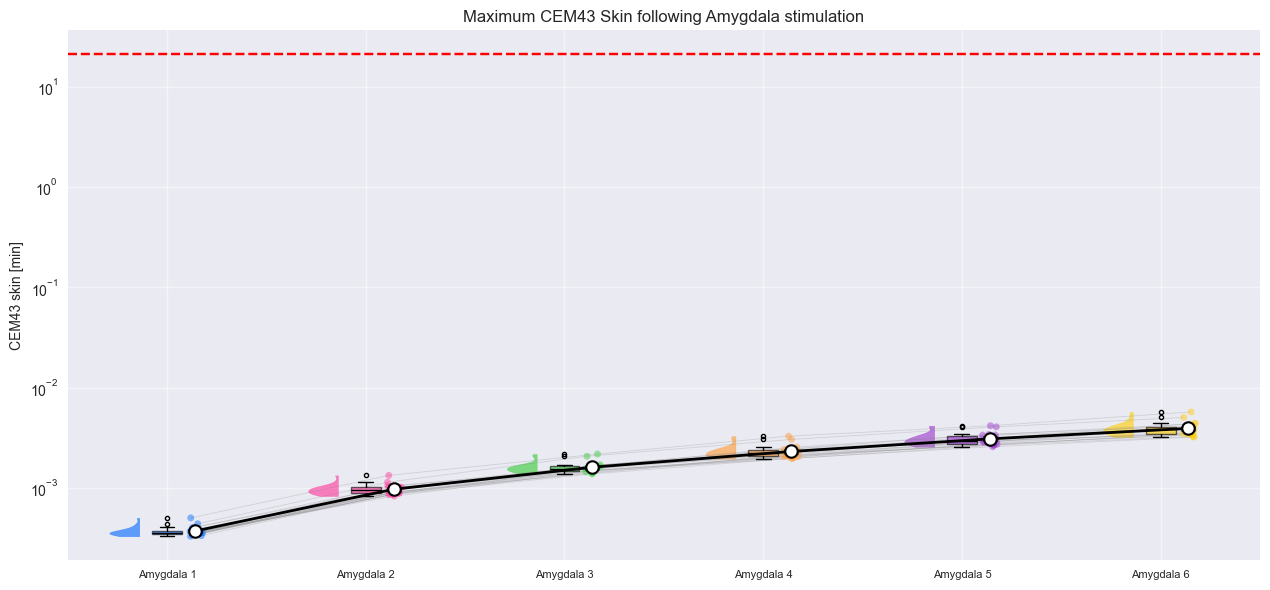

In [18]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following Amygdala stimulation',
    logarithmic_scale=True
);

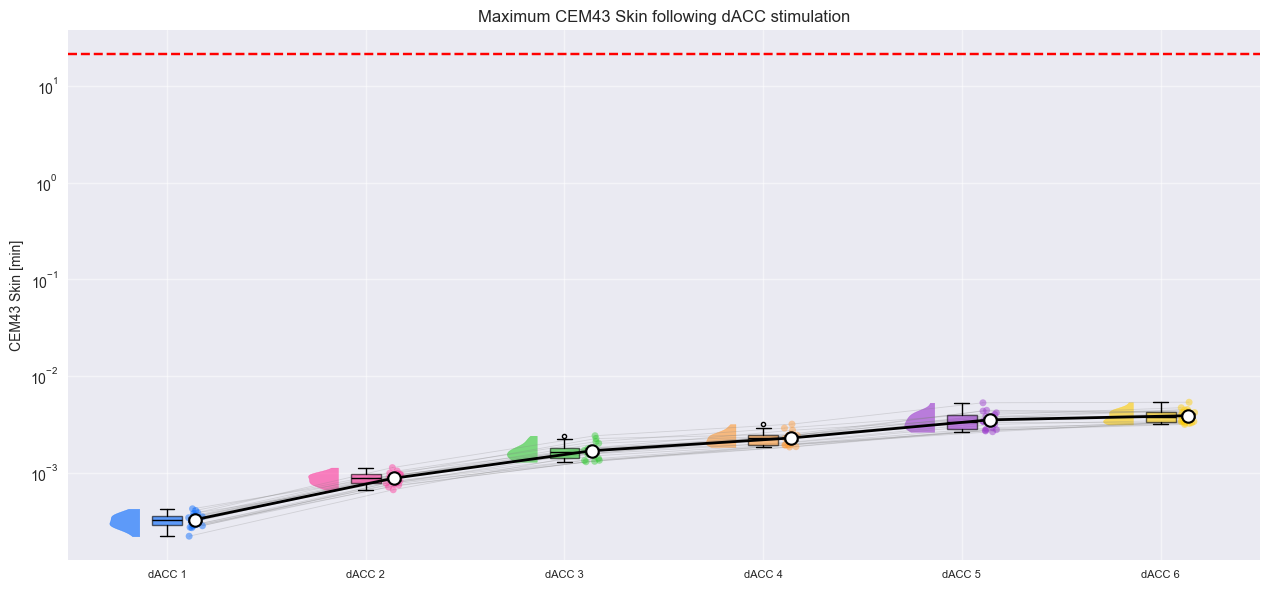

In [19]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 Skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following dACC stimulation',
    logarithmic_scale=True
);

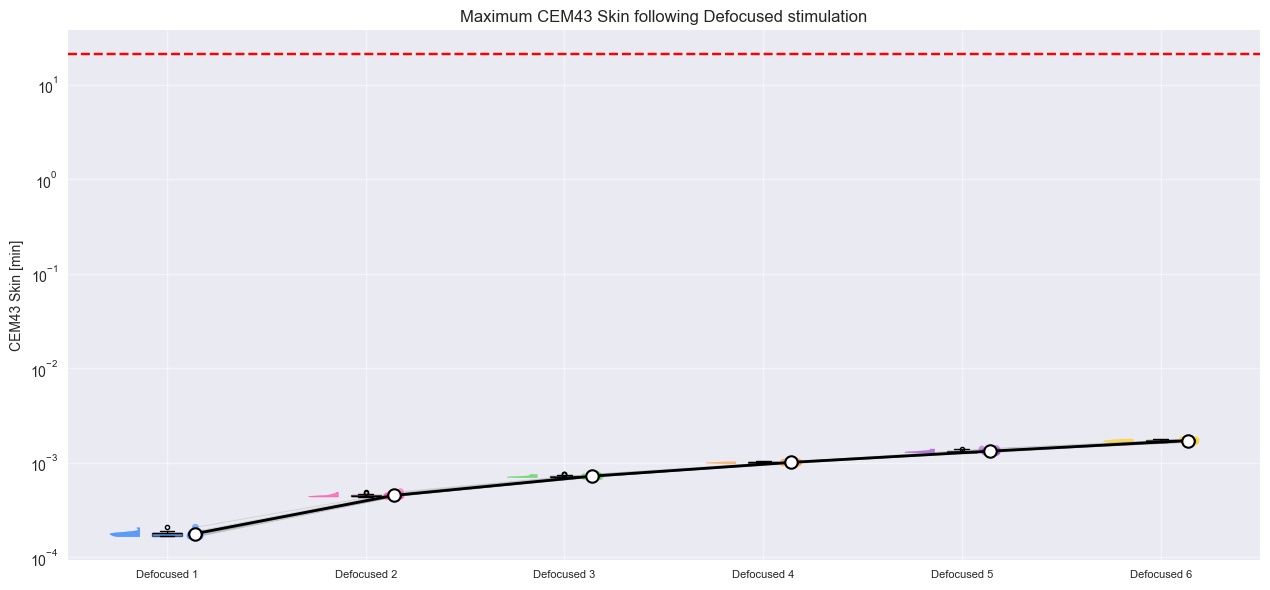

In [20]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 Skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin following Defocused stimulation',
    logarithmic_scale=True
);

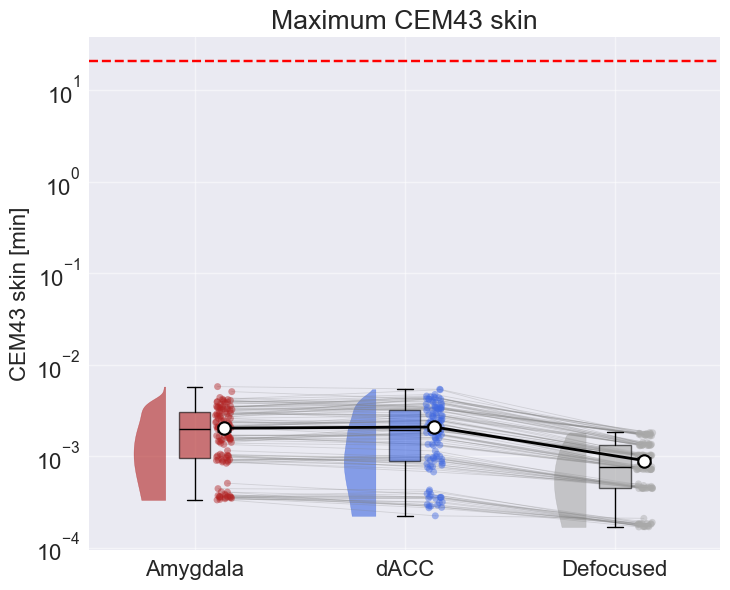

In [21]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skin [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skin',
    logarithmic_scale=True,
    font_scale=1.6
);

In [22]:
stimulation_output_exceeded = stimulation_output[stimulation_output['CEM43_skin'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','CEM43_skin']])

Empty DataFrame
Columns: [subject_id, target, CEM43_skin]
Index: []


## Brain

In [23]:
safety_limit = 2

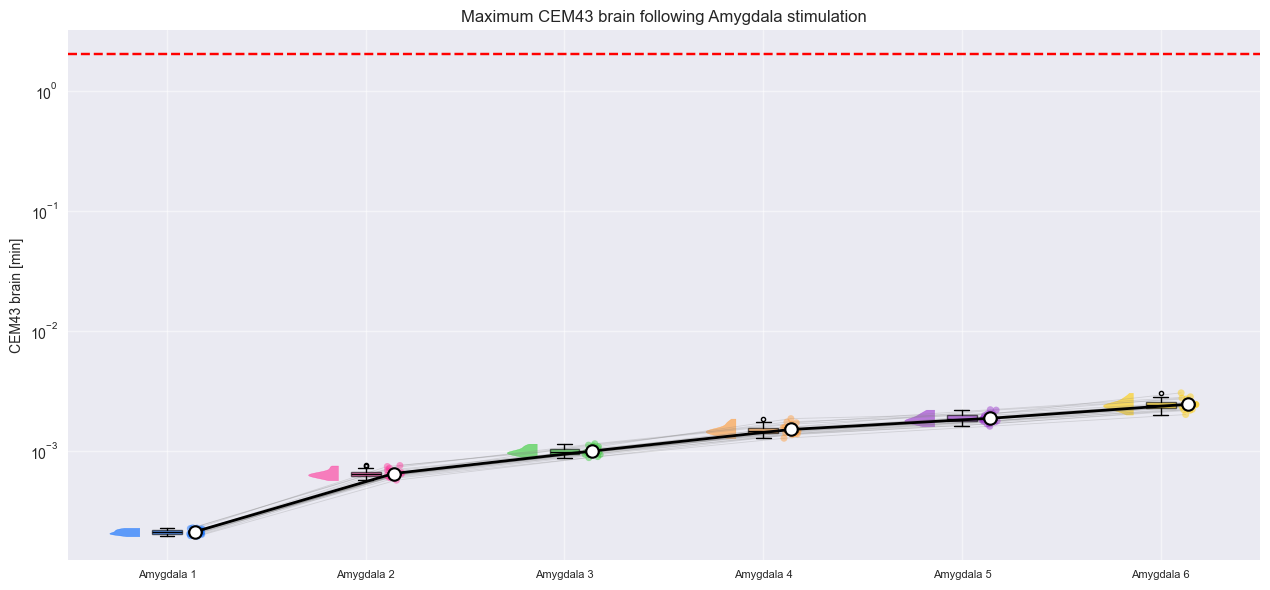

In [24]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following Amygdala stimulation',
    logarithmic_scale=True
);

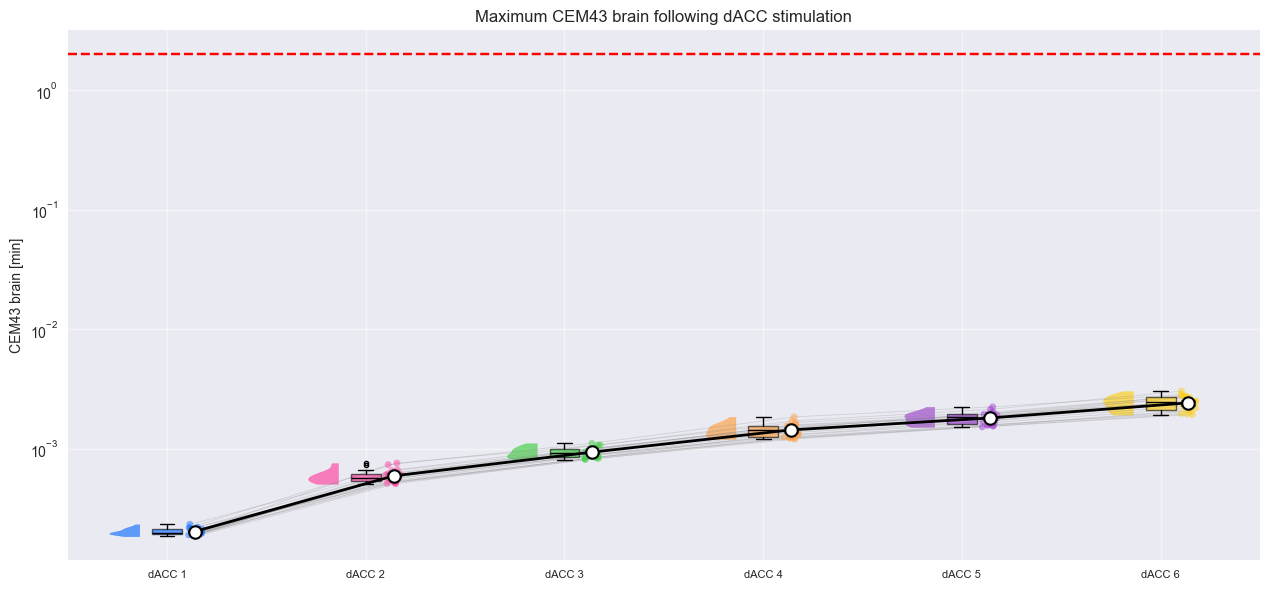

In [25]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following dACC stimulation',
    logarithmic_scale=True
);

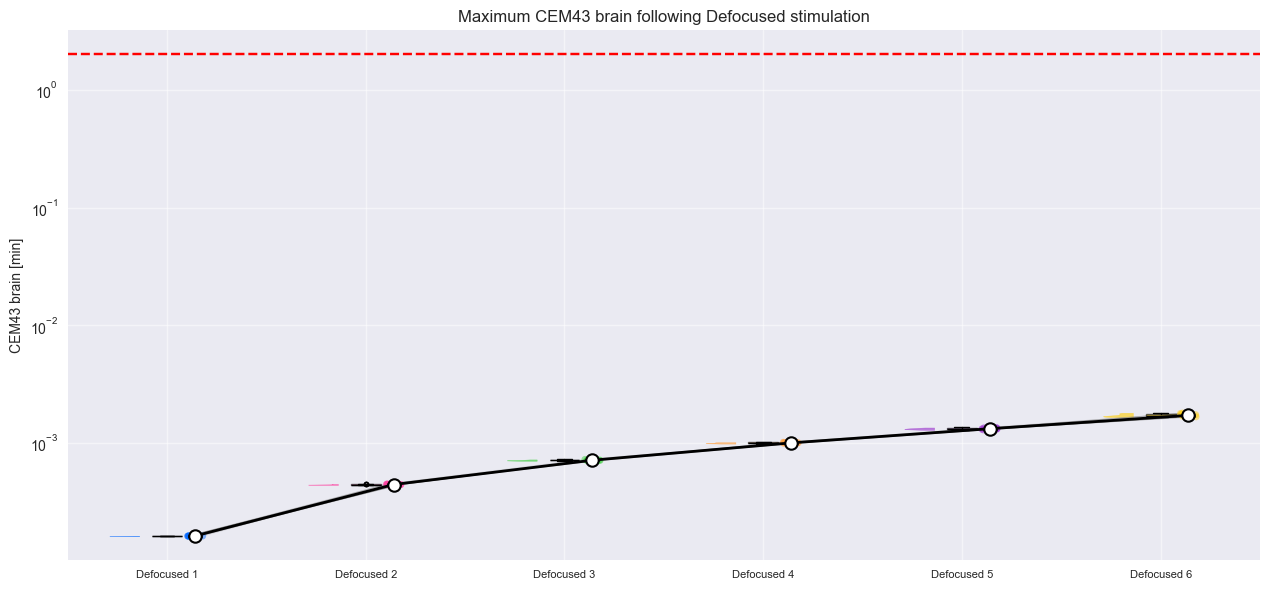

In [26]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain following Defocused stimulation',
    logarithmic_scale=True
);

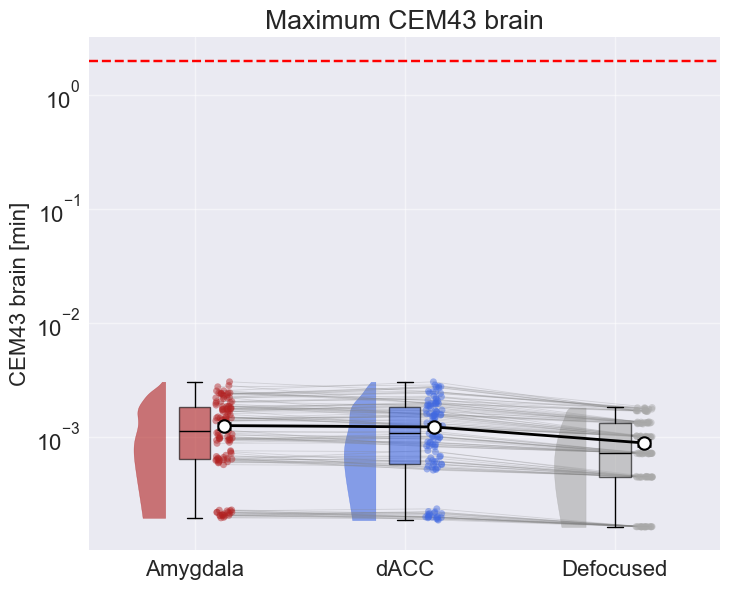

In [27]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 brain [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain',
    logarithmic_scale=True,
    font_scale=1.6
);

In [28]:
stimulation_output_exceeded = stimulation_output[stimulation_output['CEM43_brain'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','CEM43_brain']])

Empty DataFrame
Columns: [subject_id, target, CEM43_brain]
Index: []


## Skull

In [29]:
safety_limit = 16

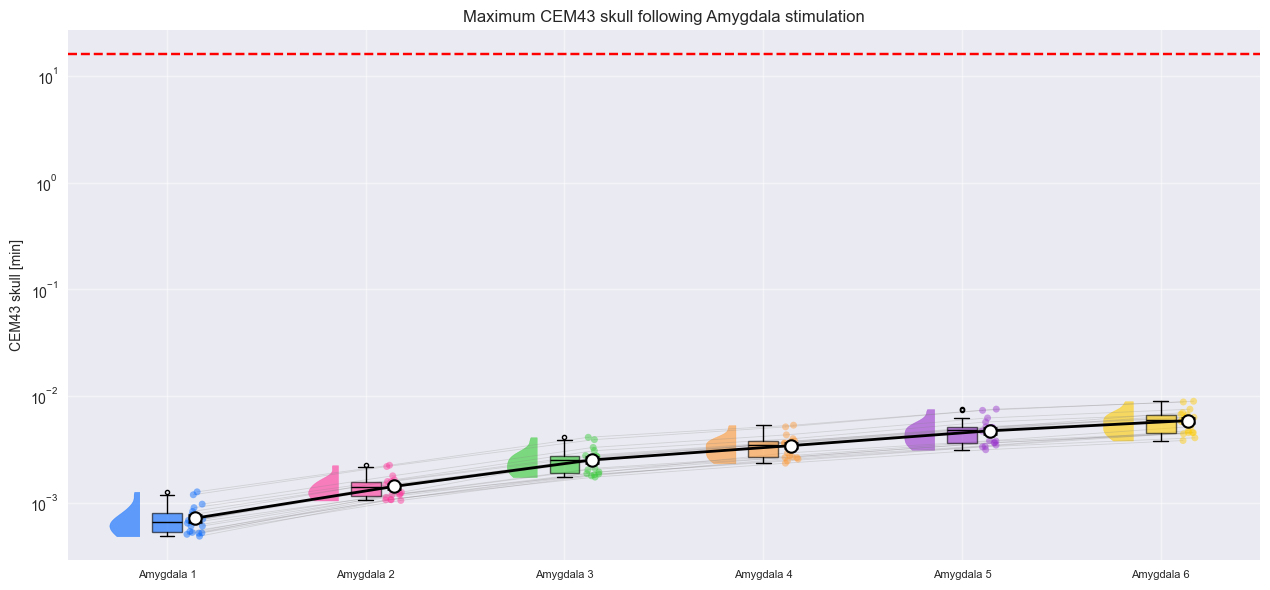

In [30]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    labels=['Amygdala 1', 'Amygdala 2', 'Amygdala 3', 'Amygdala 4', 'Amygdala 5', 'Amygdala 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following Amygdala stimulation',
    logarithmic_scale=True
);

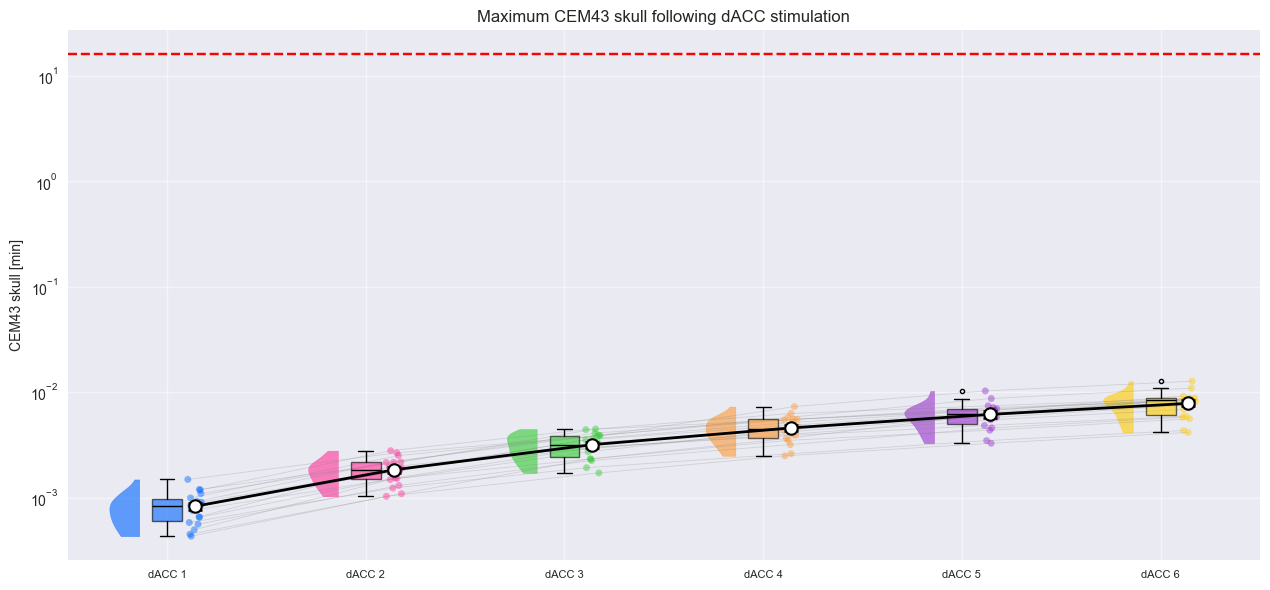

In [31]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    labels=['dACC 1', 'dACC 2', 'dACC 3', 'dACC 4', 'dACC 5', 'dACC 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following dACC stimulation',
    logarithmic_scale=True
);

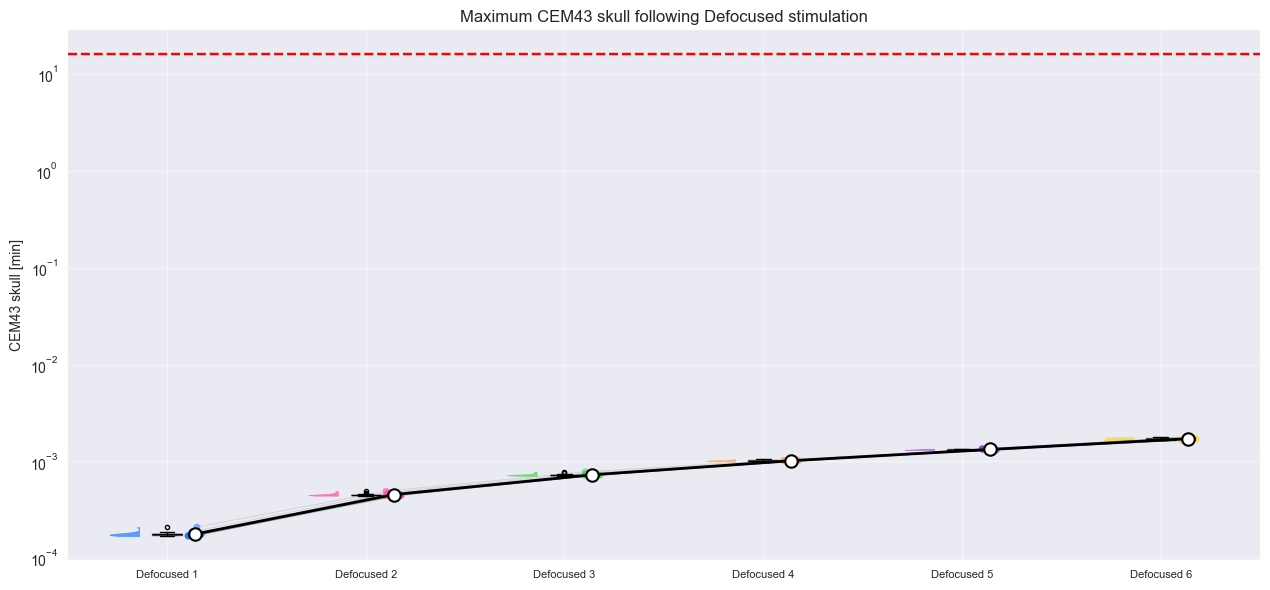

In [32]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    labels=['Defocused 1', 'Defocused 2', 'Defocused 3', 'Defocused 4', 'Defocused 5', 'Defocused 6'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull following Defocused stimulation',
    logarithmic_scale=True
);


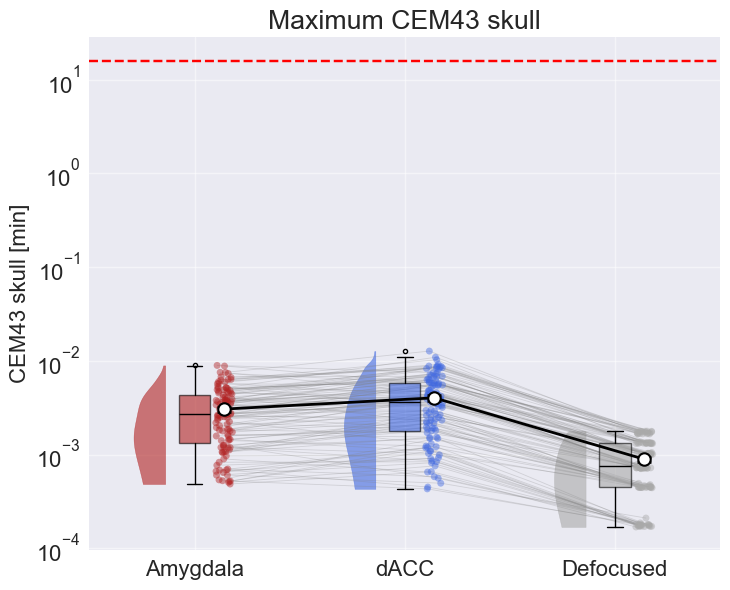

In [33]:
# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id','sub_target'],
        columns='main_target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1', 'target_2', 'target_3'],
    labels=['Amygdala', 'dACC', 'Defocused'],
    colours=['firebrick', 'royalblue','darkgrey'],
    output_dir=plot_dir,
    ylabel_name='CEM43 skull [min]',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull',
    logarithmic_scale=True,
    font_scale=1.6
);

In [34]:
stimulation_output_exceeded = stimulation_output[stimulation_output['CEM43_skull'] > safety_limit]
print(stimulation_output_exceeded[['subject_id','target','CEM43_skull']])

Empty DataFrame
Columns: [subject_id, target, CEM43_skull]
Index: []
